# MUSIC GENRE CLASSIFICATION

## Chuẩn bị dữ liệu

### Khai báo thư viện

In [88]:
import os, sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer


from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
    
from IPython import display
import warnings
warnings.filterwarnings('ignore')

### Khai báo các tham số

In [89]:
params_cfg = {
    'seed': 42,
    'exps_dir': '../../exps',
    'exp_name': 'music_genre_feat01',
    'data_dir': '../../data/music-genre',
    'verbose': False,
    'k_folds': 5
}

params_cfg.update(**{'save_dir': os.path.abspath(f'{params_cfg["exps_dir"]}/{params_cfg["exp_name"]}')})
params_cfg.update(**{'submit_dir': os.path.abspath(f'../submissions/{params_cfg["exp_name"]}')})

for v in params_cfg:
    print(f'+ {v}: {params_cfg[v]}')

+ seed: 42
+ exps_dir: ../../exps
+ exp_name: music_genre_feat01
+ data_dir: ../../data/music-genre
+ verbose: False
+ k_folds: 5
+ save_dir: d:\Data\Code\Python\ML WS\exps\music_genre_feat01
+ submit_dir: d:\Data\Code\Python\ML WS\challenge3\submissions\music_genre_feat01


### Tải dữ liệu train, test

In [90]:
df_train = pd.read_csv(f'{params_cfg['data_dir']}/train (1).csv')
df_test = pd.read_csv(f'{params_cfg['data_dir']}/test (2).csv')

display.display(df_train.head())
display.display(df_test.head())

,Id,Artist Name,Track Name,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Class
0,1,Marina Maximilian,Not Afraid,37.0,0.334,0.536,9.0,-6.649,0,0.0381,0.378000,NaN,0.106,0.235,152.429,204947.0,4,9
1,2,The Black Keys,Howlin' for You,67.0,0.725,0.747,11.0,-5.545,1,0.0876,0.027200,0.0468,0.104,0.380,132.921,191956.0,4,6
2,3,Royal & the Serpent,phuck u,NaN,0.584,0.804,7.0,-6.094,1,0.0619,0.000968,0.6350,0.284,0.635,159.953,161037.0,4,10
3,4,Detroit Blues Band,Missing You,12.0,0.515,0.308,NaN,-14.711,1,0.0312,0.907000,0.0213,0.300,0.501,172.472,298093.0,3,2
4,5,Coast Contra,My Lady,48.0,0.565,0.777,6.0,-5.096,0,0.2490,0.183000,NaN,0.211,0.619,88.311,254145.0,4,5


,Id,Artist Name,Track Name,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature
0,14397,Juan Pablo Vega,Matando (feat. Vic Mirallas),NaN,0.691,0.670,2.0,-7.093,0,0.0941,0.075700,0.035200,0.1970,0.635,89.965,200000.0,4
1,14398,Kappi Kat,Baarish,14.0,0.461,0.777,2.0,-7.469,1,0.0306,0.388000,0.923000,0.2910,0.525,163.043,283909.0,4
2,14399,Plain White T's,Hey There Delilah,80.0,0.656,0.291,2.0,-10.572,1,0.0293,0.872000,NaN,0.1140,0.298,103.971,232533.0,4
3,14400,WALK THE MOON,Different Colors,52.0,0.480,0.826,NaN,-4.602,1,0.0397,0.000797,0.000001,0.1250,0.687,96.000,222053.0,4
4,14401,Peled,◊ß◊®◊ô◊ñ,23.0,0.734,0.729,1.0,-6.381,0,0.2830,0.147000,NaN,0.0672,0.805,76.030,118439.0,4


## Preprocessing

In [91]:
popularity_median = df_train['Popularity'].median()
key_median = df_train['key'].median()
instrumentalness_median = df_train['instrumentalness'].median()
counts_map = df_train['Artist Name'].value_counts().to_dict()

def preprocess_data(df, is_train=True, is_debug=False, **kwargs):
    # Tạo bản copy để không ảnh hưởng đến dataframe gốc
    df_output = df.copy()
    
    # Tách features và target (nếu là training data)
    if is_train:
        X = df_output.drop('Class', axis=1)
        y = df_output['Class']
    else:
        X = df_output
    
    # Chuyển duratio từ phút sang mini giây
    df_output['is_originally_minutes'] = (df_output['duration_in min/ms'] < 30).astype(int)
    df_output['duration_ms'] = df_output['duration_in min/ms'].apply(lambda x: x*60000 if x<30 else x)
    df_output['duration_ms'] = np.log1p(df_output['duration_ms'])
    # Điền giá trị thiếu
    df_output['key'].fillna(key_median, inplace=True)
    df_output['Popularity'].fillna(popularity_median, inplace=True)
    df_output['instrumentalness'].fillna(instrumentalness_median, inplace=True)
    
    # Biến đổi tần suất xuất hiện của nghệ sĩ
    # df_output['Artist_Frequency'] = df_output['Artist Name'].map(counts_map).fillna(0)
    # Drop cột Id, Track Name
    df_output.drop(['Id', 'Artist Name', 'Track Name', 'duration_in min/ms'], axis=1, inplace=True, errors='ignore')
    
    # Thêm cột target trở lại nếu là training data
    if is_train:
        df_output['Class'] = y

    
    if is_debug:
        print(f"Missing values after preprocessing: {df_output.isnull().sum().sum()}")
        print(f"Final shape: {df_output.shape}")

    return df_output

In [92]:
print("\nPreprocessing training data...")
print("----------------------------")
df_train_processed = preprocess_data(df_train, is_train=True, is_debug=False)
print("\nPreprocessing test data...")
print("----------------------------")
df_test_processed = preprocess_data(df_test, is_train=False, is_debug=False)


Preprocessing training data...
----------------------------

Preprocessing test data...
----------------------------


In [93]:
df_train_processed['duration_ms'].describe()

count    14396.000000
mean        12.320188
std          0.299507
min         10.312280
25%         12.140648
50%         12.300480
75%         12.477839
max         14.399491
Name: duration_ms, dtype: float64

Kiểm tra lại giá trị thiếu

In [94]:
print(f"Missing in Train: {df_train_processed.isna().sum().sum()}")
print(f"Missing in Test: {df_test_processed.isna().sum().sum()}")

Missing in Train: 0
Missing in Test: 0


## Feature engineering

In [95]:
def feature_engineering(df):
    # 1. Tạo đặc trưng từ Speechiness (Dựa trên ngưỡng 0.33 và 0.66)
    # 0: Music, 1: Mixed, 2: Speech
    conditions = [
        (df['speechiness'] < 0.33),
        (df['speechiness'] >= 0.33) & (df['speechiness'] <= 0.66),
        (df['speechiness'] > 0.66)
    ]
    choices = [0, 1, 2]
    df['speech_category'] = np.select(conditions, choices, default=0)

    # 2. Tạo đặc trưng từ Instrumentalness (Ngưỡng 0.5)
    # Điền giá trị thiếu bằng 0 trước khi so sánh
    df['is_instrumental'] = (df['instrumentalness'] >= 0.5).astype(int)

    # 3. Tạo đặc trưng từ Liveness (Ngưỡng 0.8)
    df['is_live'] = (df['liveness'] >= 0.8).astype(int)
    
    # 4. Binning Popularity thành các nhóm
    df['Pop_Cat'] = pd.cut(df['Popularity'], bins=5, labels=False)
    
    return df

df_train_feat = feature_engineering(df_train_processed)
df_test_feat = feature_engineering(df_test_processed)

In [96]:
df_train_feat.shape

(14396, 20)

## Model training

### Baseline

In [97]:
base_models = {
    'CatBoost': CatBoostClassifier(random_state=params_cfg['seed'], verbose=False, allow_writing_files=False, train_dir=None),
    'LightGBM': LGBMClassifier(random_state=params_cfg['seed'], verbose=-1),
    'XGBoost': XGBClassifier(random_state=params_cfg['seed']),
    'Random Forest': RandomForestClassifier(random_state=params_cfg['seed']),
    'Extra Trees': ExtraTreesClassifier(random_state=params_cfg['seed']),
}

In [98]:
X_train = df_train_feat.drop('Class', axis=1)
y_train = df_train_feat['Class']

results = []
names = []

for name, model in base_models.items():
    # Dùng StratifiedKFold để đảm bảo tỉ lệ Class đều nhau ở các fold
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=params_cfg['seed'])
    
    pipeline = Pipeline(steps=[
        ('scaler', RobustScaler()),
        ('model', model)
    ])
    
    # Tính điểm
    cv_results = cross_val_score(pipeline, X_train, y_train, cv=kfold, scoring='accuracy')
    
    results.append(cv_results)
    names.append(name)
    print(f"{name}: Mean Accuracy = {cv_results.mean():.4f} (Std: {cv_results.std():.4f})")

CatBoost: Mean Accuracy = 0.5307 (Std: 0.0040)
LightGBM: Mean Accuracy = 0.5220 (Std: 0.0044)
LightGBM: Mean Accuracy = 0.5220 (Std: 0.0044)
XGBoost: Mean Accuracy = 0.5124 (Std: 0.0110)
XGBoost: Mean Accuracy = 0.5124 (Std: 0.0110)
Random Forest: Mean Accuracy = 0.5102 (Std: 0.0059)
Random Forest: Mean Accuracy = 0.5102 (Std: 0.0059)
Extra Trees: Mean Accuracy = 0.5019 (Std: 0.0054)
Extra Trees: Mean Accuracy = 0.5019 (Std: 0.0054)


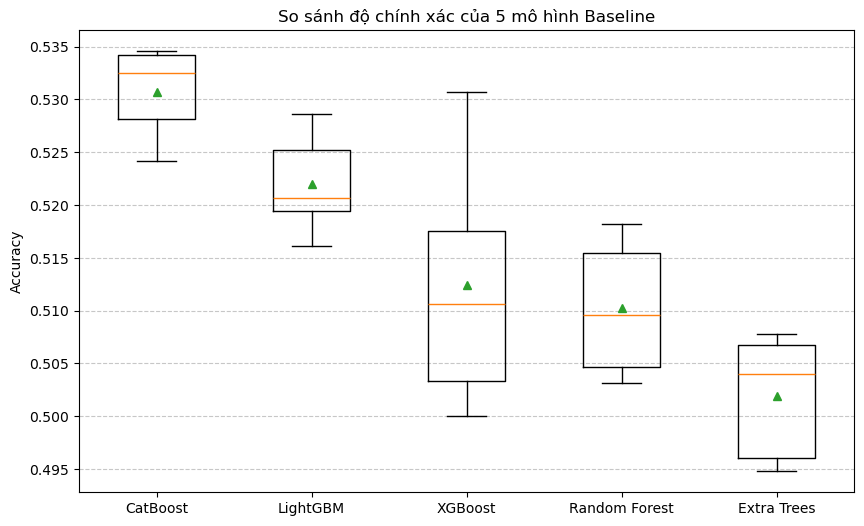

In [99]:
plt.figure(figsize=(10, 6))
plt.boxplot(results, labels=names, showmeans=True)
plt.title('So sánh độ chính xác của 5 mô hình Baseline')
plt.ylabel('Accuracy')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

### Tuning

In [100]:
param_distributions = {
    'CatBoost': {
        'iterations': randint(100, 1000),           # Số lượng cây
        'depth': randint(4, 10),                    # Độ sâu của cây (CatBoost nhạy cảm với cái này)
        'learning_rate': uniform(0.01, 0.2),        # Tốc độ học (0.01 đến 0.21)
        'l2_leaf_reg': randint(1, 10),              # Regularization (chống overfitting)
        'border_count': randint(32, 255)            # Số lượng điểm cắt cho biến số
    },
    'LightGBM': {
        'n_estimators': randint(100, 1000),
        'learning_rate': uniform(0.01, 0.2),
        'num_leaves': randint(20, 150),             # Quan trọng nhất của LightGBM
        'max_depth': randint(5, 15),                # Giới hạn độ sâu để tránh overfitting
        'min_child_samples': randint(10, 100),      # Số lượng mẫu tối thiểu trong 1 lá
        'subsample': uniform(0.6, 0.4),             # Lấy mẫu dòng (0.6 đến 1.0)
        'colsample_bytree': uniform(0.6, 0.4)       # Lấy mẫu cột
    },
    'XGBoost': {
        'n_estimators': randint(100, 1000),
        'learning_rate': uniform(0.01, 0.2),
        'max_depth': randint(3, 10),
        'min_child_weight': randint(1, 10),         # Kiểm soát việc chia nhánh
        'gamma': uniform(0, 5),                     # Giảm loss tối thiểu để chia nhánh
        'subsample': uniform(0.6, 0.4),
        'colsample_bytree': uniform(0.6, 0.4)
    },
    'Random Forest': {
        'n_estimators': randint(100, 500),
        'max_depth': [None] + list(range(10, 50)),  # None hoặc độ sâu cụ thể
        'min_samples_split': randint(2, 20),
        'min_samples_leaf': randint(1, 10),
        'max_features': ['sqrt', 'log2', None],
        'bootstrap': [True, False]
    },
    'Extra Trees': {
        'n_estimators': randint(100, 500),
        'max_depth': [None] + list(range(10, 50)),
        'min_samples_split': randint(2, 20),
        'min_samples_leaf': randint(1, 10),
        'max_features': ['sqrt', 'log2', None],
        'bootstrap': [True, False]
    }
}

In [101]:
best_estimators = {}
results_tuning = {}

for model_name in base_models.keys():
    print(f"\nTuning {model_name}...")
    
    # Lấy model và param grid
    model = base_models[model_name]
    param_grid = param_distributions[model_name]
    
    # Tạo pipeline
    pipeline = Pipeline(steps=[
        ('scaler', RobustScaler()),
        ('model', model)
    ])
    
    param_grid_prefixed = {f"model__{k}": v for k, v in param_grid.items()}
    # RandomizedSearchCV
    random_search = RandomizedSearchCV(
        pipeline,
        param_grid_prefixed,
        n_iter=20,
        cv=3,
        scoring='accuracy',
        random_state=42,
        n_jobs=-1
    )
    
    random_search.fit(X_train, y_train)
    
    # In kết quả
    best_accuracy = random_search.best_score_
    print(f"- Best Accuracy: {best_accuracy:.4f}")
    print(f"- Best params: {random_search.best_params_}")

    # Lưu kết quả
    results_tuning[model_name] = best_accuracy
    best_estimators[model_name] = random_search.best_estimator_


Tuning CatBoost...
- Best Accuracy: 0.5490
- Best params: {'model__border_count': 76, 'model__depth': 4, 'model__iterations': 956, 'model__l2_leaf_reg': 7, 'model__learning_rate': 0.09468029614127392}

Tuning LightGBM...
- Best Accuracy: 0.5490
- Best params: {'model__border_count': 76, 'model__depth': 4, 'model__iterations': 956, 'model__l2_leaf_reg': 7, 'model__learning_rate': 0.09468029614127392}

Tuning LightGBM...
- Best Accuracy: 0.5204
- Best params: {'model__colsample_bytree': 0.8650089137415928, 'model__learning_rate': 0.07234221521788219, 'model__max_depth': 10, 'model__min_child_samples': 63, 'model__n_estimators': 205, 'model__num_leaves': 23, 'model__subsample': 0.6739417822102108}

Tuning XGBoost...
- Best Accuracy: 0.5204
- Best params: {'model__colsample_bytree': 0.8650089137415928, 'model__learning_rate': 0.07234221521788219, 'model__max_depth': 10, 'model__min_child_samples': 63, 'model__n_estimators': 205, 'model__num_leaves': 23, 'model__subsample': 0.6739417822102

In [102]:
os.makedirs(params_cfg['save_dir'], exist_ok=True)

# Lưu models
for model_name, model in best_estimators.items():
    filename = f"{model_name.replace(' ', '_').lower()}_best_model.pkl"
    filepath = os.path.join(params_cfg['save_dir'], filename)
    joblib.dump(model, filepath)
    print(f"Saved: {filename}")

Saved: catboost_best_model.pkl
Saved: lightgbm_best_model.pkl
Saved: lightgbm_best_model.pkl
Saved: xgboost_best_model.pkl
Saved: random_forest_best_model.pkl
Saved: xgboost_best_model.pkl
Saved: random_forest_best_model.pkl
Saved: extra_trees_best_model.pkl
Saved: extra_trees_best_model.pkl


In [103]:
# Hiển thị ranking tất cả models
print("\nMODEL RANKING:")
for model_name, accuracy in sorted(results_tuning.items(), key=lambda x: x[1], reverse=True):
    print(f"{model_name:20}: {accuracy:.4f}")


MODEL RANKING:
CatBoost            : 0.5490
XGBoost             : 0.5464
Random Forest       : 0.5357
Extra Trees         : 0.5254
LightGBM            : 0.5204


## Submit

In [104]:
os.makedirs(params_cfg['submit_dir'], exist_ok=True)

for model_name in ['XGBoost', 'CatBoost', 'Random Forest']:
    
    best_estimators[model_name].fit(X_train, y_train)

    preds = best_estimators[model_name].predict(df_test_processed)
    preds = np.asarray(preds)
    # Nếu là proba (2D, >1 col) -> argmax
    if preds.ndim == 2 and preds.shape[1] > 1:
        preds = preds.argmax(axis=1)
    # Nếu là (n,1) -> flatten
    elif preds.ndim == 2 and preds.shape[1] == 1:
        preds = preds.ravel()
    df_submission = pd.DataFrame({
        'Id': df_test['Id'],
        'Class': preds
    })

    df_submission.to_csv(f"{params_cfg['submit_dir']}/submission_{model_name.replace(' ', '_').lower()}.csv", index=False)

### Stacking

In [ ]:
# Stacking ensemble
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import joblib
import os
import numpy as np
import pandas as pd

# Chọn các base estimators từ best_estimators (nếu tồn tại)
estimator_names = ['CatBoost', 'XGBoost', 'Random Forest', 'Extra Trees']
estimators = []
for name in estimator_names:
    if name in best_estimators:
        # Lấy estimator (có thể là Pipeline gồm scaler + model)
        estimators.append((name.replace(' ', '_').lower(), best_estimators[name]))

if len(estimators) == 0:
    raise ValueError('Không tìm thấy base estimators trong `best_estimators`. Vui lòng chạy ô tuning trước.')

# Tạo StackingClassifier với LogisticRegression làm meta-estimator
stack_clf = StackingClassifier(estimators=estimators,
                               final_estimator=LogisticRegression(max_iter=1000),
                               cv=5,
                               n_jobs=-1,
                               passthrough=False)

# Đánh giá bằng cross-validation (độ chính xác)
print('\nEvaluating stacking with 5-fold CV...')
cv_scores = cross_val_score(stack_clf, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
print(f'Stacking CV Accuracy: mean={cv_scores.mean():.4f}, std={cv_scores.std():.4f}')

# Huấn luyện trên toàn bộ tập huấn luyện
print('Fitting stacking on full training data...')
stack_clf.fit(X_train, y_train)

# Lưu model stacking
joblib.dump(stack_clf, os.path.join(params_cfg['save_dir'], 'stacking_model_04.pkl'))
print('Saved stacking model to', os.path.join(params_cfg['save_dir'], 'stacking_model_04.pkl'))

# Dự đoán trên test set và tạo file submission
preds = stack_clf.predict(df_test_processed)
preds = np.asarray(preds)
if preds.ndim == 2 and preds.shape[1] > 1:
    preds = preds.argmax(axis=1)
elif preds.ndim == 2 and preds.shape[1] == 1:
    preds = preds.ravel()

df_submission = pd.DataFrame({
    'Id': df_test['Id'],
    'Class': preds
})

submission_path = f"{params_cfg['submit_dir']}/submission_stacking_04.csv"
df_submission.to_csv(submission_path, index=False)
print('Saved submission to', submission_path)


Evaluating stacking with 5-fold CV...
Stacking CV Accuracy: mean=0.5549, std=0.0114
Fitting stacking on full training data...
Stacking CV Accuracy: mean=0.5549, std=0.0114
Fitting stacking on full training data...
Saved stacking model to d:\Data\Code\Python\ML WS\exps\music_genre_feat01\stacking_model_04.pkl
Saved stacking model to d:\Data\Code\Python\ML WS\exps\music_genre_feat01\stacking_model_04.pkl
Saved submission to d:\Data\Code\Python\ML WS\challenge3\submissions\music_genre_feat01/submission_stacking.csv
Saved submission to d:\Data\Code\Python\ML WS\challenge3\submissions\music_genre_feat01/submission_stacking.csv
